In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/order_items.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/customer_master.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/ecommerce_sales_customer_analytics_150k.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/dataset_statistics.csv
/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/product_catalog.csv


# E-Commerce Data Cleaning and Preprocessing

This project focuses on exploring, cleaning, and preparing an e-commerce dataset for further data analysis.

The cleaning process will include checking for missing values, duplicate records, incorrect data types, inconsistent text entries, date formatting issues, and other data quality problems.

In [2]:
import pandas as pd 
import numpy as np

file_path = ('/kaggle/input/datasets/datascikhan/e-commerce-sales-and-customer-analytics/ecommerce_sales_customer_analytics_150k.csv')
df = pd.read_csv(file_path)
df.head()

,order_id,order_date,order_time,order_status,sales_channel,customer_id,customer_name,customer_age,gender,customer_segment,...,discount_amount,tax_amount,shipping_cost,net_sales,product_cost,profit,profit_margin_percentage,customer_lifetime_value,is_repeat_customer,customer_order_count
0,ORD-301242,2023-11-06,16:37:47,Completed,Mobile App,CUST-003102,Jasmine Ryan,55,Male,Consumer,...,477.89,61.07,12.03,945.40,588.33,345.04,36.50,12459.68,True,11
1,ORD-773460,2025-12-24,01:22:36,Completed,Website,CUST-003124,Scott Chase,26,Male,Premium,...,1456.06,320.83,9.00,2018.41,2031.88,-22.47,-1.11,13032.48,True,11
2,ORD-449374,2021-07-05,14:24:21,Completed,Mobile App,CUST-012496,Marc Wheeler,69,Female,Premium,...,97.30,29.79,13.05,468.35,257.73,197.57,42.18,6159.44,True,6
3,ORD-567636,2023-01-21,07:20:26,Completed,Social Media,CUST-023928,Jennifer Smith,65,Male,Consumer,...,53.34,34.39,20.85,546.52,277.84,247.83,45.35,5638.30,True,7
4,ORD-820028,2022-05-13,09:46:21,Completed,Social Media,CUST-012730,Jessica Wang,34,Female,Consumer,...,133.63,421.35,23.03,2785.27,1231.88,1530.36,54.94,13240.10,True,8


In [3]:
df.shape

(138116, 46)

In [4]:
df.columns

Index(['order_id', 'order_date', 'order_time', 'order_status', 'sales_channel',
       'customer_id', 'customer_name', 'customer_age', 'gender',
       'customer_segment', 'customer_type', 'customer_city', 'customer_state',
       'customer_country', 'region', 'customer_postal_code', 'payment_method',
       'payment_status', 'currency', 'shipping_method', 'warehouse',
       'delivery_days', 'estimated_delivery_days', 'delivery_status',
       'return_status', 'return_reason', 'customer_rating', 'review_sentiment',
       'customer_review', 'marketing_channel', 'campaign_name', 'coupon_code',
       'loyalty_points_earned', 'loyalty_points_redeemed', 'quantity',
       'gross_sales', 'discount_amount', 'tax_amount', 'shipping_cost',
       'net_sales', 'product_cost', 'profit', 'profit_margin_percentage',
       'customer_lifetime_value', 'is_repeat_customer',
       'customer_order_count'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 46 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   order_id                  138116 non-null  object 
 1   order_date                138116 non-null  object 
 2   order_time                138116 non-null  object 
 3   order_status              138116 non-null  object 
 4   sales_channel             138116 non-null  object 
 5   customer_id               138116 non-null  object 
 6   customer_name             138116 non-null  object 
 7   customer_age              138116 non-null  int64  
 8   gender                    138116 non-null  object 
 9   customer_segment          138116 non-null  object 
 10  customer_type             138116 non-null  object 
 11  customer_city             138116 non-null  object 
 12  customer_state            138116 non-null  object 
 13  customer_country          138116 non-null  o

In [6]:
df.duplicated().sum()

np.int64(0)

## 1. Missing Values Analysis

Before cleaning the dataset, I will examine the amount and percentage of missing values in each column to determine whether the missing data represents an error or a valid absence of information.

In [7]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df)
) * 100

missing_summary = pd.DataFrame({
    'Missing Values': missing_count,
    'Percentage': missing_percentage
})

missing_summary = missing_summary[
    missing_summary['Missing Values'] > 0
].sort_values(
    by='Percentage',
    ascending=False
)

missing_summary

,Missing Values,Percentage
return_status,128654,93.149237
return_reason,128654,93.149237
coupon_code,110502,80.006661
campaign_name,83233,60.263112
delivery_days,24557,17.779982
customer_rating,24557,17.779982
estimated_delivery_days,24557,17.779982
customer_review,24557,17.779982
review_sentiment,24557,17.779982


The dataset contains no fully duplicated rows.

### Understanding Missing Values

Before deciding how to handle missing values, I will inspect related categorical columns to determine whether the missing values represent actual data quality issues or valid cases where the information does not apply.

In [8]:
df['return_status'].value_counts(dropna=False)

return_status
NaN         128654
Returned      9462
Name: count, dtype: int64

In [9]:
df['return_reason'].value_counts(dropna=False)

return_reason
NaN                        128654
Wrong Product                1237
Other                        1208
Changed Mind                 1204
Size Issue                   1182
Defective Product            1174
Late Delivery                1172
Product Not as Expected      1147
Damaged Product              1138
Name: count, dtype: int64

In [10]:
df[['return_status', 'return_reason']].value_counts(dropna=False)

return_status  return_reason          
NaN            NaN                        128654
Returned       Wrong Product                1237
               Other                        1208
               Changed Mind                 1204
               Size Issue                   1182
               Defective Product            1174
               Late Delivery                1172
               Product Not as Expected      1147
               Damaged Product              1138
Name: count, dtype: int64

In [11]:
df['return_status'] = df['return_status'].fillna('Not Returned')
df['return_reason'] = df['return_reason'].fillna('Not Applicable')

In [12]:
df[['return_status', 'return_reason']].value_counts(dropna=False)

return_status  return_reason          
Not Returned   Not Applicable             128654
Returned       Wrong Product                1237
               Other                        1208
               Changed Mind                 1204
               Size Issue                   1182
               Defective Product            1174
               Late Delivery                1172
               Product Not as Expected      1147
               Damaged Product              1138
Name: count, dtype: int64

### Handling Return-Related Missing Values

The missing values in `return_status` and `return_reason` were found to be structurally related. All orders marked as returned had a valid return reason, while orders without a return had missing values in both fields.

Therefore:
- Missing `return_status` values were replaced with **"Not Returned"**
- Missing `return_reason` values were replaced with **"Not Applicable"**

These values were not treated as data errors because the information does not apply to non-returned orders.

In [13]:
df['coupon_code'].value_counts(dropna=False).head(20)

coupon_code
NaN       110502
SAVE39       731
SAVE49       727
SAVE40       719
SAVE12       716
SAVE33       715
SAVE26       712
SAVE25       711
SAVE15       709
SAVE36       709
SAVE46       707
SAVE44       704
SAVE21       704
SAVE27       702
SAVE22       702
SAVE13       701
SAVE17       701
SAVE43       699
SAVE18       699
SAVE19       693
Name: count, dtype: int64

In [14]:
df.groupby(df['coupon_code'].isnull())['discount_amount'].agg(['count', 'mean', 'min', 'max'])

,count,mean,min,max
coupon_code,,,,
False,27614,235.821261,0.0,5046.32
True,110502,238.071515,0.0,6759.02


In [15]:
df['coupon_code'] = df['coupon_code'].fillna('No Coupon')

In [16]:
df['coupon_code'].value_counts(dropna=False).head(10)

coupon_code
No Coupon    110502
SAVE39          731
SAVE49          727
SAVE40          719
SAVE12          716
SAVE33          715
SAVE26          712
SAVE25          711
SAVE15          709
SAVE36          709
Name: count, dtype: int64

### Handling Coupon Code Missing Values

Missing values in `coupon_code` indicate orders where no coupon was used. These values were replaced with **"No Coupon"** to make the data more explicit and easier to interpret.


In [17]:
df['campaign_name'].value_counts(dropna=False)

campaign_name
NaN                   83233
Default_Campaign      22989
Google_Search_Q1       2748
Google_Shopping        2746
Google_Display         2731
FB_Retargeting         2270
FB_Dynamic             2233
Friend_Invite          2232
Referral_Program       2198
FB_Prospecting         2161
Insta_Influencer       1822
Insta_Reels            1799
Insta_Stories          1773
Abandoned_Cart         1520
Weekly_Newsletter      1459
Promo_Email            1459
Influencer_Program     1404
Affiliate_Partner      1339
Name: count, dtype: int64

In [18]:
df.groupby(df['campaign_name'].isnull())['marketing_channel'].value_counts()

campaign_name  marketing_channel
False          Organic Search       11009
               Google Ads            8225
               Direct                8182
               Facebook Ads          6664
               Instagram             5394
               Email Marketing       4438
               Referral              4430
               Affiliate             2743
               TikTok                2201
               YouTube               1597
True           Organic Search       16733
               Google Ads           12408
               Direct               12333
               Facebook Ads          9987
               Instagram             8407
               Email Marketing       6780
               Referral              6761
               Affiliate             4105
               TikTok                3236
               YouTube               2483
Name: count, dtype: int64

In [19]:
pd.crosstab(
    df['marketing_channel'],
    df['campaign_name'].isnull(),
    normalize='index'
) * 100

campaign_name,False,True
marketing_channel,,
Affiliate,40.055491,59.944509
Direct,39.883012,60.116988
Email Marketing,39.561419,60.438581
Facebook Ads,40.021620,59.978380
Google Ads,39.863326,60.136674
Instagram,39.084124,60.915876
Organic Search,39.683512,60.316488
Referral,39.585381,60.414619
TikTok,40.481883,59.518117


In [20]:
df['campaign_name'] = df['campaign_name'].fillna('Unknown Campaign')

In [21]:
df['campaign_name'].value_counts(dropna=False).head(10)

campaign_name
Unknown Campaign    83233
Default_Campaign    22989
Google_Search_Q1     2748
Google_Shopping      2746
Google_Display       2731
FB_Retargeting       2270
FB_Dynamic           2233
Friend_Invite        2232
Referral_Program     2198
FB_Prospecting       2161
Name: count, dtype: int64

### Handling Campaign Name Missing Values

Missing values in `campaign_name` were present across all marketing channels at a similar rate. Since the missing values could not be confidently interpreted as orders with no campaign, they were replaced with **"Unknown Campaign"** rather than **"No Campaign"**.


In [22]:
df.loc[
    df['delivery_days'].isnull(),
    ['order_status', 'delivery_status']
].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

### Delivery Days Missing Values

All missing values in `delivery_days` correspond to orders with a `delivery_status` of **"Cancelled"**. Since these orders were not successfully delivered, an actual delivery duration does not exist.

Therefore, the missing values in `delivery_days` were kept as `NaN` rather than being replaced with an artificial numeric value such as 0.


In [23]:
(
    df['delivery_days'].isnull()
    !=
    df['estimated_delivery_days'].isnull()
).sum()

np.int64(0)

### Estimated Delivery Days Missing Values

The missing values in `estimated_delivery_days` occur in exactly the same rows as the missing values in `delivery_days`. These rows correspond to orders with a delivery status of **"Cancelled"**.

Therefore, the missing values were kept as `NaN` because no delivery duration was recorded for cancelled orders.


In [24]:
df.loc[
    df['customer_rating'].isnull(),
    ['order_status', 'delivery_status']
].value_counts(dropna=False)

order_status  delivery_status
Returned      Cancelled          9462
Cancelled     Cancelled          8398
Pending       Cancelled          6697
Name: count, dtype: int64

### Customer Rating Missing Values

All missing values in `customer_rating` occur in rows where the `delivery_status` is **"Cancelled"**. Since these orders were not successfully delivered, a customer rating was not expected.

Therefore, the missing values were kept as `NaN` rather than being replaced with a numeric value such as 0.


In [25]:
(
    df['customer_rating'].isnull()
    !=
    df['customer_review'].isnull()
).sum()

np.int64(0)

### Customer Review Missing Values

The missing values in `customer_review` occur in exactly the same rows as the missing values in `customer_rating`. These rows correspond to orders with a delivery status of **"Cancelled"**.

Therefore, the missing values were kept as `NaN` because no customer review was expected for cancelled orders.


In [26]:
(
    df['customer_rating'].isnull()
    !=
    df['review_sentiment'].isnull()
).sum()

np.int64(0)

### Review Sentiment Missing Values

The missing values in `review_sentiment` occur in exactly the same rows as the missing values in `customer_rating` and `customer_review`. These rows correspond to cancelled deliveries.

Therefore, the missing values were kept as `NaN` because no review sentiment was expected when no customer review was provided.


In [27]:
df.isnull().sum()[df.isnull().sum() > 0].sort_values(ascending=False)

delivery_days              24557
estimated_delivery_days    24557
customer_rating            24557
review_sentiment           24557
customer_review            24557
dtype: int64

### Missing Values Summary

After examining the missing values, several columns were cleaned based on their meaning:

* Missing `return_status` values were replaced with **"Not Returned"**.
* Missing `return_reason` values were replaced with **"Not Applicable"**.
* Missing `coupon_code` values were replaced with **"No Coupon"**.
* Missing `campaign_name` values were replaced with **"Unknown Campaign"**.

The remaining missing values are in `delivery_days`, `estimated_delivery_days`, `customer_rating`, `customer_review`, and `review_sentiment`. These values all correspond to cancelled deliveries, so they were intentionally kept as `NaN` because the information does not apply to those orders.


In [28]:
df[['order_date', 'order_time']].head(10)

,order_date,order_time
0,2023-11-06,16:37:47
1,2025-12-24,01:22:36
2,2021-07-05,14:24:21
3,2023-01-21,07:20:26
4,2022-05-13,09:46:21
5,2021-02-10,10:05:47
6,2021-05-03,02:55:44
7,2022-10-13,21:19:50
8,2022-12-06,17:22:52
9,2023-09-19,18:38:32


In [29]:
df['order_date'] = pd.to_datetime(
    df['order_date'],
    format='%Y-%m-%d'
)

In [30]:
df['order_date'].dtype

dtype('<M8[ns]')

In [31]:
df['order_time'] = pd.to_datetime(
    df['order_time'],
    format='%H:%M:%S'
).dt.time

In [32]:
df['order_time'].dtype

dtype('O')

In [33]:
df['order_time'].head()

0    16:37:47
1    01:22:36
2    14:24:21
3    07:20:26
4    09:46:21
Name: order_time, dtype: object

## 2. Date and Time Parsing

The `order_date` and `order_time` columns were initially stored as `object` data types.

* `order_date` was converted to a proper `datetime` format using the structure `YYYY-MM-DD`.
* `order_time` was parsed using the format `HH:MM:SS` and stored as time values.

This makes the date information easier to use for further analysis, such as extracting the year, month, or day.


In [34]:
df['order_status'].value_counts(dropna=False)

order_status
Completed    113559
Returned       9462
Cancelled      8398
Pending        6697
Name: count, dtype: int64

In [35]:
df['gender'].value_counts(dropna=False)

gender
Female        66439
Male          66284
Non-Binary     5393
Name: count, dtype: int64

In [36]:
df['payment_method'].value_counts(dropna=False)

payment_method
Credit Card          41460
Debit Card           27635
PayPal               20750
Digital Wallet       16382
Cash on Delivery     13863
Buy Now Pay Later    11061
Bank Transfer         6965
Name: count, dtype: int64

In [37]:
df['customer_country'].value_counts(dropna=False)

customer_country
USA          82600
UK           20235
Germany      11593
Canada        7015
Australia     6794
India         5707
UAE           4172
Name: count, dtype: int64

In [38]:
df['customer_city'].value_counts(dropna=False).head(20)

customer_city
Lake Michael        166
South Michael       163
South James         129
Port Michael        112
East Michael        105
New Robert          103
West Michael        101
New David            97
West Christopher     96
Smithmouth           91
Port Robert          90
South John           90
North William        86
South Jessica        86
North David          85
Lake James           84
Port Jennifer        83
New John             83
New Christopher      83
New Jennifer         82
Name: count, dtype: int64

In [39]:
print("Original unique cities:", df['customer_city'].nunique())

clean_city = df['customer_city'].str.lower().str.strip()

print("Unique cities after basic cleaning:", clean_city.nunique())

Original unique cities: 15516
Unique cities after basic cleaning: 15516


In [40]:
df['customer_state'].value_counts(dropna=False).head(20)

customer_state
Pennsylvania         9148
California           8523
New York             8431
Georgia              8384
Michigan             8227
Ohio                 8207
Texas                8048
Illinois             8017
North Carolina       7874
Florida              7741
England              5213
Northern Ireland     5168
Scotland             4933
Wales                4921
North Rhine          2507
Baden-Württemberg    2344
Hesse                2310
Lower Saxony         2231
Bavaria              2201
British Columbia     1583
Name: count, dtype: int64

In [41]:
print("Original unique states:", df['customer_state'].nunique())

clean_state = df['customer_state'].str.lower().str.strip()

print("Unique states after basic cleaning:", clean_state.nunique())

Original unique states: 38
Unique states after basic cleaning: 38


In [42]:
df['sales_channel'].value_counts(dropna=False)

sales_channel
Mobile App      55318
Website         48237
Marketplace     20698
Social Media    13863
Name: count, dtype: int64

In [43]:
df['customer_segment'].value_counts(dropna=False)

customer_segment
Consumer    75636
Premium     34746
VIP         13957
Business    13777
Name: count, dtype: int64

In [44]:
df['customer_age'].describe()

count    138116.000000
mean         45.862681
std          16.467676
min          18.000000
25%          32.000000
50%          46.000000
75%          60.000000
max          74.000000
Name: customer_age, dtype: float64

In [45]:
df['quantity'].describe()

count    138116.000000
mean          5.615244
std           3.371289
min           1.000000
25%           3.000000
50%           5.000000
75%           8.000000
max          24.000000
Name: quantity, dtype: float64

In [46]:
df['gross_sales'].describe()

count    138116.000000
mean       1375.384176
std        1291.009554
min           6.310000
25%         458.920000
50%         995.730000
75%        1871.200000
max       16051.190000
Name: gross_sales, dtype: float64

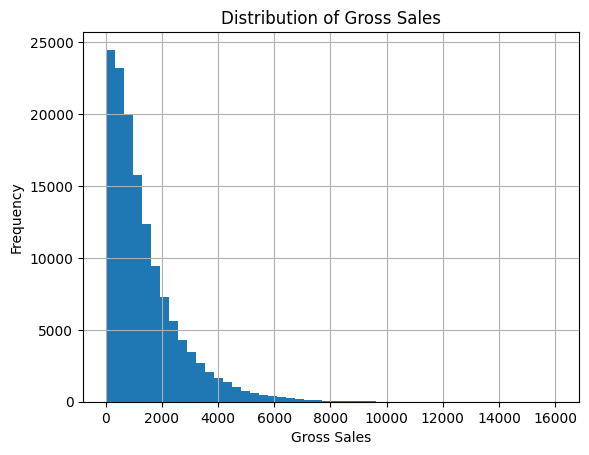

In [47]:
import matplotlib.pyplot as plt

df['gross_sales'].hist(bins=50)

plt.title('Distribution of Gross Sales')
plt.xlabel('Gross Sales')
plt.ylabel('Frequency')
plt.show()

In [48]:
df['gross_sales'].skew()

np.float64(1.909648449769334)

In [49]:
from scipy import stats

df['gross_sales_normalized'], lambda_value = stats.boxcox(df['gross_sales'])

print("Original skewness:", df['gross_sales'].skew())
print("Normalized skewness:", df['gross_sales_normalized'].skew())
print("Lambda:", lambda_value)

Original skewness: 1.909648449769334
Normalized skewness: -0.02905167660798835
Lambda: 0.234399476487523


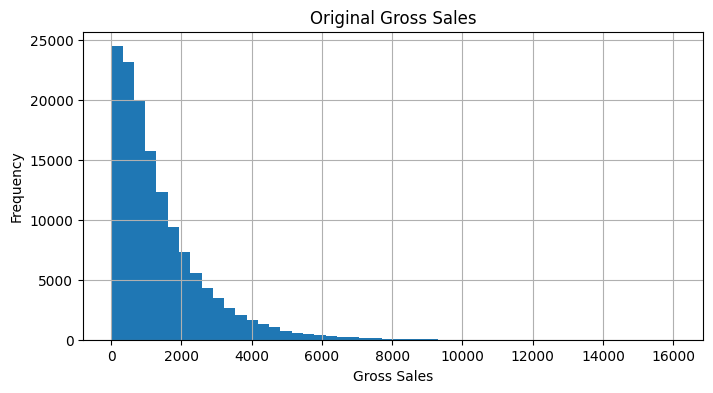

In [50]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
df['gross_sales'].hist(bins=50)
plt.title('Original Gross Sales')
plt.xlabel('Gross Sales')
plt.ylabel('Frequency')
plt.show()

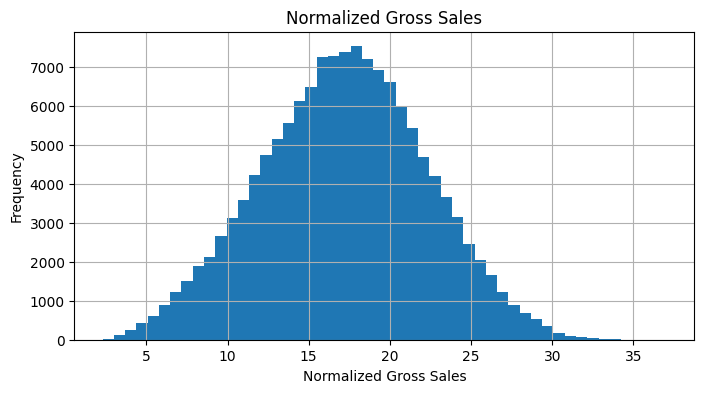

In [51]:
plt.figure(figsize=(8, 4))

df['gross_sales_normalized'].hist(bins=50)

plt.title('Normalized Gross Sales')
plt.xlabel('Normalized Gross Sales')
plt.ylabel('Frequency')

plt.show()

### Gross Sales Normalization

The original `gross_sales` distribution was positively skewed, with a skewness of approximately **1.91**.

A Box-Cox transformation was applied to create a normalized version of the variable. After transformation, the skewness decreased to approximately **-0.03**, indicating a much more symmetric distribution that is closer to a normal distribution.

The original `gross_sales` column was preserved, while the transformed values were stored in a new column called `gross_sales_normalized`.

In [52]:
df[['customer_age', 'customer_lifetime_value']].describe()

,customer_age,customer_lifetime_value
count,138116.000000,138116.000000
mean,45.862681,8971.639047
std,16.467676,4430.506588
min,18.000000,22.550000
25%,32.000000,5713.570000
50%,46.000000,8392.525000
75%,60.000000,11651.030000
max,74.000000,30268.440000


In [53]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[['customer_age_scaled', 'customer_lifetime_value_scaled']] = scaler.fit_transform(
    df[['customer_age', 'customer_lifetime_value']]
)

In [54]:
df[
    [
        'customer_age',
        'customer_age_scaled',
        'customer_lifetime_value',
        'customer_lifetime_value_scaled'
    ]
].head()

,customer_age,customer_age_scaled,customer_lifetime_value,customer_lifetime_value_scaled
0,55,0.660714,12459.68,0.411201
1,26,0.142857,13032.48,0.430139
2,69,0.910714,6159.44,0.202900
3,65,0.839286,5638.30,0.185670
4,34,0.285714,13240.10,0.437003


### Feature Scaling

The `customer_age` and `customer_lifetime_value` features were on very different numeric scales.

Min-Max Scaling was applied to transform both features into a range between 0 and 1. The original columns were preserved, and the scaled values were stored in new columns for potential use in machine learning models.

In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138116 entries, 0 to 138115
Data columns (total 49 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   order_id                        138116 non-null  object        
 1   order_date                      138116 non-null  datetime64[ns]
 2   order_time                      138116 non-null  object        
 3   order_status                    138116 non-null  object        
 4   sales_channel                   138116 non-null  object        
 5   customer_id                     138116 non-null  object        
 6   customer_name                   138116 non-null  object        
 7   customer_age                    138116 non-null  int64         
 8   gender                          138116 non-null  object        
 9   customer_segment                138116 non-null  object        
 10  customer_type                   138116 non-null  object 

In [56]:
print("Duplicate rows:", df.duplicated().sum())

print("\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Duplicate rows: 0

Remaining missing values:
delivery_days              24557
estimated_delivery_days    24557
customer_rating            24557
review_sentiment           24557
customer_review            24557
dtype: int64


In [57]:
df.to_csv(
    "ecommerce_cleaned.csv",
    index=False,
    encoding="utf-8"
)

In [58]:
import os

os.path.exists("ecommerce_cleaned.csv")

True

## Conclusion

In this project, I cleaned and prepared an e-commerce dataset containing **138,116 records and 46 original features** for further analysis and machine learning.

The main data cleaning and preprocessing steps included:

- Checked the dataset structure, column names, data types, and duplicate records.
- Confirmed that the dataset contained **0 fully duplicated rows**.
- Investigated missing values instead of removing or filling them automatically.
- Replaced missing `return_status` values with **"Not Returned"** and missing `return_reason` values with **"Not Applicable"**.
- Replaced missing `coupon_code` values with **"No Coupon"**.
- Replaced missing `campaign_name` values with **"Unknown Campaign"** after examining their relationship with marketing channels.
- Kept missing values in `delivery_days`, `estimated_delivery_days`, `customer_rating`, `customer_review`, and `review_sentiment` because they corresponded to cancelled deliveries and were therefore logically unavailable.
- Converted `order_date` from an object data type to a proper datetime format and parsed the order time values.
- Checked several categorical columns for inconsistent text entries and found no major formatting inconsistencies.
- Examined numerical features such as customer age, quantity, and gross sales for unreasonable values.
- Identified a positively skewed distribution in `gross_sales` and applied a **Box-Cox transformation**, reducing skewness from approximately **1.91 to -0.03**.
- Applied **Min-Max Scaling** to `customer_age` and `customer_lifetime_value`, transforming them to a range between 0 and 1 while preserving the original columns.
- Performed a final quality check to confirm that only intentionally missing values remained.

After preprocessing, the dataset contained **49 columns**, including the newly created normalized and scaled features.

The cleaned dataset was saved as:

`ecommerce_cleaned.csv`

This project helped me apply the concepts learned in the **Kaggle Data Cleaning course** to a real-world e-commerce dataset and better understand how data quality decisions should be based on the meaning and context of the data rather than simply removing missing values.